In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
import requests
import xlsxwriter
import math
import matplotlib.pyplot as plt
import ta
from itertools import batched

ALPHA VANTAGE data fetching

In [5]:

stock = "AES"
api_key = "L4FO9CN0DRLQH8EJ"
url = f'https://www.alphavantage.co/query?function=OVERVIEW&symbol={stock}&apikey={api_key}'
r = requests.get(url)
overview_data = r.json()

#print(data)
MarketCap =(overview_data["MarketCapitalization"])#Parameter extraction for single stock
print(MarketCap)




9641157000


Market Cap from YFinance

In [9]:
symbol = yf.Ticker("AES")
fast_market_cap = symbol.fast_info.market_cap
print(fast_market_cap/1000000000,"Billion")

9.641156756197448 Billion


S&P stock analysis using DataFrame

OHLCV(Day Timestanmp*) data using Yfinance

In [10]:
# Download data
data = yf.download("AES", start="2025-08-28", end="2025-08-29")
# Ensure "Close" is 1D Series
close = data["Close"].squeeze()
print(data.tail())#Full data


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\4275462972.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AES", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed

Price       Close   High   Low   Open   Volume
Ticker        AES    AES   AES    AES      AES
Date                                          
2025-08-28  13.48  13.56  13.3  13.44  7638700


Perticular Data from Tail Data

In [11]:
Closing_data = data["Close"].iloc[-1].item()
print(Closing_data)
Volume = data["Volume"].iloc[-1].item()
print(Volume)

13.479999542236328
7638700


In [12]:
my_columns = ["Ticker", "Close","MarketCap", "Volume", "No of Shares to buy"]
final_dataframe = pd.DataFrame(columns=my_columns)

# Using append (older way, works but deprecated in Pandas >= 2.0)
final_dataframe.loc[len(final_dataframe)] = {
    "Ticker": symbol,
    "Close": Closing_data,
    "MarketCap": MarketCap,
    "Volume": Volume,
    "No of Shares to buy": "N/A"
}
print(final_dataframe)


                         Ticker  Close   MarketCap   Volume  \
0  yfinance.Ticker object <AES>  13.48  9641157000  7638700   

  No of Shares to buy  
0                 N/A  


In [56]:
#Equal weight S&P 500
stocks = pd.read_excel("C:/Users/ADMIN/Downloads/HireTrade/S&P 500 Companies (Standard and Poor 500).xlsx")
final_dataframe = pd.DataFrame(columns=my_columns)

for symbol in stocks["Symbol"] :
        try:
          stock = yf.Ticker(f"{symbol}")
     
          fast_market_cap = getattr(stock,"fast_info", None)
          if not data.empty:
             market_cap = getattr(fast_market_cap, "market_cap", None)
          else :
            market_cap = "N/A"
              
          data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
          
          if not data.empty:
            close = data["Close"].iloc[-1].item() if "Close" in data else "N/A"
            volume = data["Volume"].iloc[-1].item() if "Volume" in data else "N/A"
          else:
            close, volume = "N/A", "N/A"
          
     # Ensure "Close" is 1D Series
          close = data["Close"].squeeze()
          final_dataframe.loc[len(final_dataframe)] = {
               "Ticker":symbol,
               "Close" :close,
               "MarketCap":market_cap if fast_market_cap is not None else "N/A",
               "Volume": volume,
              # "No of Shares to buy":'N/A'
     }
        except Exception as e:
           print(f"Error fetching {symbol}: {e}")
print(final_dataframe)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default t

Error fetching BIG: 'currentTradingPeriod'


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default t

Error fetching CHK: 'currentTradingPeriod'


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default t

...

Error fetching SRCL: 'currentTradingPeriod'


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default t

Error fetching X: 'currentTradingPeriod'


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['UTX']: YFTzMissingError('possibly delisted; no timezone found')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\2505515674.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{symbol}", start="2025-08-28", end="2025-08-29")
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\250

    Ticker                                   Close            MarketCap  \
0      MMM                              157.559998   82839945738.296875   
1      NaN                                   10.93     338716310.244942   
2      ABT                              131.369995     230889434218.875   
3      ANF                               96.519997    4456077790.841675   
4      ACN                              256.170013  161923093090.558594   
..     ...                                     ...                  ...   
484    XYL                              144.009995                  N/A   
485   YHOO  Series([], Name: YHOO, dtype: float64)                 None   
486    YUM                              145.470001                  N/A   
487    ZMH   Series([], Name: ZMH, dtype: float64)                 None   
488   ZION                                   57.82                  N/A   

      Volume  No of Shares to buy  
0    2982200                  NaN  
1      31500               

In [ ]:
for chunk in batched(stocks["Symbol"],100):
   print(chunk)
   data = yf.download(f"{chunk}", start="2025-08-26", end="2025-08-27")
   close = data["Close"].squeeze()

('MMM', nan, 'ABT', 'ANF', 'ACN', 'ADBE', 'AMD', 'AES', 'AET', 'AFL', 'A', 'GAS', 'APD', 'ARG', 'AKAM', 'AA', 'ALXN', 'ATI', 'AGN', 'ALL', 'ANR', 'ALTR', 'MO', 'AMZN', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AMP', 'ABC', 'AMGN', 'APH', 'APC', 'ADI', 'AON', 'APA', 'AIV', 'APOL', 'AAPL', 'AMAT', 'ADM', 'AIZ', 'T', 'ADSK', 'ADP', 'AN', 'AZO', 'AVB', 'AVY', 'AVP', 'BHI', 'BLL', 'BAC', 'BK', 'BCR', 'BAX', 'BBT', 'BEAM', 'BDX', 'BBBY', 'BMS', 'BRK.B', 'BBY', 'BIG', 'BIIB', 'BLK', 'HRB', 'BMC', 'BA', 'BWA', 'BXP', 'BSX', 'BMY', 'BRCM', 'BF.B', 'CHRW', 'CA', 'CVC', 'COG', 'CAM', 'CPB', 'COF', 'CAH', 'CFN', 'KMX', 'CCL', 'CAT', 'CBG', 'CBS', 'CELG', 'CNP', 'CTL', 'CERN', 'CF', 'SCHW', 'CHK', 'CVX', 'CMG', 'CB')


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\1864997867.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{chunk}", start="2025-08-26", end="2025-08-27")
[*********************101%***********************]  101 of 100 completed

103 Failed downloads:
["'USB'", "'HOT'", "'WM'", "'SHLD'", "'ZMH'", "'TRIP'", "'SYMC'", "'TE'", "'WU'", "'TER'", "'DIS'", "'TDC'", "'UNP'", "'SYY'", "'WFM'", "'X'", "'XLNX'", "'WHR'", "'TROW'", "'SRE'", "'TSS'", "'WEC'", "'WPX'", "'VZ'", "'SYK'", "'ZION')", "'UPS'", "'TIE'", "'WPI'", "'SBUX'", "'SPG'", "'AN'", "'WAG'", "'BK'", "'CFN'", "'BBY'", "'CHK'", "'ALL'", "'AMZN'", "'ARG'", "'AMD'", "'BBT'", "'BHI'", "'AEE'", "'BIG'", "'CAM'", "'AMP'", "'CCL'", "'ALTR'", "'BLK'", "'BCR'", "'CBG'", "'BBBY'", "'CB')", "'BMY'", "'AVB'", "'AKAM'", "'CA'", "'COG'", "'AAPL'", "'BRK.B'", "'APC'", "'CVC'", "'BEAM'", "('MMM'", "'ALXN'", "'ATI'", "'CHRW'", "'CTL'", "'MO'", "'APA'", "'ADP'", "'AIG'", "'AMGN'", "'AET'", "'

('CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CTXS', 'CLF', 'CLX', 'CME', 'CMS', 'COH', 'KO', 'CCE', 'CTSH', 'CL', 'CMCSA', 'CMA', 'CSC', 'CAG', 'COP', 'CNX', 'ED', 'STZ', 'CBE', 'GLW', 'COST', 'CVH', 'COV', 'CCI', 'CSX', 'CMI', 'CVS', 'DHI', 'DHR', 'DRI', 'DVA', 'DF', 'DE', 'DELL', 'DNR', 'XRAY', 'DVN', 'DV', 'DO', 'DTV', 'DFS', 'DISCA', 'DLTR', 'D', 'RRD', 'DOV', 'DOW', 'DPS', 'DTE', 'DD', 'DUK', 'DNB', 'ETFC', 'EMN', 'ETN', 'EBAY', 'ECL', 'EIX', 'EW', 'EA', 'EMC', 'EMR', 'ESV', 'ETR', 'EOG', 'EQT', 'EFX', 'EQR', 'EL', 'EXC', 'EXPE', 'EXPD', 'ESRX', 'XOM', 'FFIV', 'FDO', 'FAST', 'FII', 'FDX', 'FIS', 'FITB', 'FHN', 'FSLR', 'FE', 'FISV', 'FLIR', 'FLS', 'FLR', 'FMC', 'FTI', 'F', 'FRX', 'FOSL', 'BEN', 'FCX')


[*********************100%***********************]  99 of 100 completed

100 Failed downloads:
["'BMS'", "'AON'", "'APOL'", "'ABT'", "'AGN'", "'BSX'", "'ANR'", "'AEP'", "'KMX'", "'AIV'", "'AZO'", "'ABC'", "'BDX'", "'BRCM'", "'BIIB'", "'ADBE'", "'CVX'", "'CPB'", "'CELG'", "'CERN'", "'AVY'", "'CBS'", "'AES'", "'BF.B'", "'COF'", "'GAS'", "'BA'", "'AMAT'", "'CBE'", "'CMCSA'", "'DUK'", "'FTI'", "'CTXS'", "'DFS'", "'EW'", "'ETR'", "'COH'", "'CCI'", "'DRI'", "'EXPD'", "'CINF'", "'CME'", "'FII'", "'EXPE'", "'CNX'", "'COV'", "'DELL'", "'ED'", "'FE'", "'DD'", "'FLS'", "'ESRX'", "'COP'", "('CI'", "'FITB'", "'ESV'", "'EOG'", "'C'", "'CCE'", "'CTSH'", "'CSC'", "'CMA'", "'XRAY'", "'FDO'", "'FHN'", "'BEN'", "'EMR'", "'EA'", "'EMC'", "'FLR'", "'DHI'", "'CLX'", "'DTV'", "'EMN'", "'CVH'", "'FISV'", "'DTE'", "'DVA'", "'FFIV'", "'CVS'", "'FDX'", "'DF'", "'DHR'", "'CSX'", "'D'", "'FIS'", "'EL'", "'CTAS'", "'DISCA'", "'FCX')", "'FAST'", "'EXC'", "'ECL'", "'DOW'", "'EBAY'", "'FOSL'", "'DOV'", "'DNR'", "'FRX'

('FTR', 'GME', 'GCI', 'GPS', 'GD', 'GE', 'GIS', 'GPC', 'GNW', 'GILD', 'GS', 'GT', 'GOOG', 'GWW', 'HAL', 'HOG', 'HAR', 'HRS', 'HIG', 'HAS', 'HCP', 'HCN', 'HNZ', 'HP', 'HES', 'HPQ', 'HD', 'HON', 'HRL', 'HSP', 'HST', 'HCBK', 'HUM', 'HBAN', 'ITW', 'IR', 'TEG', 'INTC', 'ICE', 'IBM', 'IFF', 'IGT', 'IP', 'IPG', 'INTU', 'ISRG', 'IVZ', 'IRM', 'JBL', 'JEC', 'JDSU', 'JNJ', 'JCI', 'JOY', 'JPM', 'JNPR', 'K', 'KEY', 'KMB', 'KIM', 'KMI', 'KLAC', 'KSS', 'KFT', 'KR', 'LLL', 'LH', 'LRCX', 'LM', 'LEG', 'LEN', 'LUK', 'LXK', 'LIFE', 'LLY', 'LTD', 'LNC', 'LLTC', 'LMT', 'L', 'LO', 'LOW', 'LSI', 'MTB', 'M', 'MRO', 'MPC', 'MAR', 'MMC', 'MAS', 'MA', 'MAT', 'MKC', 'MCD', 'MHP', 'MCK', 'MJN', 'MWV', 'MDT', 'MRK')


[**                     4%                       ]  4 of 100 completed

KeyboardInterrupt: 

[**********************76%***********            ]  76 of 100 completed

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33040\1211269461.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AES",start="2025-07-20", end="2025-08-27")
[*********************100%***********************]  1 of 1 completed


Price       Close   High    Low   Open   Volume SMA50 SMA200        RSI
Ticker        AES    AES    AES    AES      AES                        
Date                                                                   
2025-08-20  13.20  13.45  13.01  13.36  6568600   NaN    NaN  49.523819
2025-08-21  12.97  13.19  12.89  13.16  6464600   NaN    NaN  43.973118
2025-08-22  13.49  13.52  13.03  13.07  6481500   NaN    NaN  55.984652
2025-08-25  13.49  13.62  13.31  13.41  6339600   NaN    NaN  55.984652
2025-08-26  13.34  13.54  13.34  13.49  6535900   NaN    NaN  52.237985


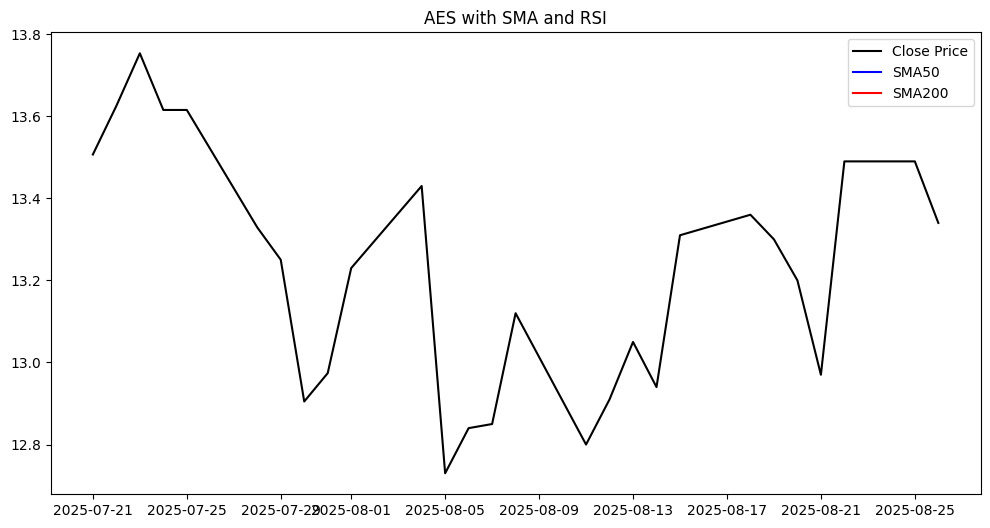

{'address1': '4300 Wilson Boulevard', 'address2': '11th Floor', 'city': 'Arlington', 'state': 'VA', 'zip': '22203', 'country': 'United States', 'phone': '703 522 1315', 'website': 'https://www.aes.com', 'industry': 'Utilities - Diversified', 'industryKey': 'utilities-diversified', 'industryDisp': 'Utilities - Diversified', 'sector': 'Utilities', 'sectorKey': 'utilities', 'sectorDisp': 'Utilities', 'longBusinessSummary': 'The AES Corporation, together with its subsidiaries, operates as a power generation and utility company in the United States and internationally. The company owns and/or operates power plants to generate and sell power to customers, such as utilities, industrial users, and other intermediaries; owns and/or operates utilities to generate or purchase, distribute, transmit, and sell electricity to end-user customers in the residential, commercial, industrial, and governmental sectors; and generates and sells electricity on the wholesale market. It uses various fuels and t

'print(ticker.financials)# Income Statement\nprint(ticker.recommendations)\nprint(ticker.balance_sheet)        # Balance Sheet\nprint(ticker.cashflow)             # Cash Flow\nprint(ticker.get_sustainability()) # ESG scores\nprint(ticker.news)  '

In [20]:
data = yf.download("AES",start="2025-07-20", end="2025-08-27")

# Ensure "Close" is 1D Series
close = data["Close"].squeeze()

# Add indicators
data["SMA50"] = ta.trend.sma_indicator(close, window=50)
data["SMA200"] = ta.trend.sma_indicator(close, window=200)
data["RSI"] = ta.momentum.rsi(close, window=14)

# Preview
print(data.tail())

# Plot chart
plt.figure(figsize=(12,6))
plt.plot(data.index, data["Close"], label="Close Price", color="black")
plt.plot(data.index, data["SMA50"], label="SMA50", color="blue")
plt.plot(data.index, data["SMA200"], label="SMA200", color="red")
plt.title("AES with SMA and RSI")
plt.legend()
plt.show()
ticker = yf.Ticker("AES")
print(ticker.get_info())           # Company fundamentals
"""print(ticker.financials)# Income Statement
print(ticker.recommendations)
print(ticker.balance_sheet)        # Balance Sheet
print(ticker.cashflow)             # Cash Flow
print(ticker.get_sustainability()) # ESG scores
print(ticker.news)  """               # Latest news

In [94]:
api_key = "L4FO9CN0DRLQH8EJ"
url = f'https://www.alphavantage.co/query?function=OVERVIEW&symbol={symbol}&apikey={api_key}'
r = requests.get(url)
overview_data = r.json()
print(overview_data)

{}


Taking Portfolio in Account

In [53]:
portfolio_size = input("Enter the value of your portfolio:")

try:
    val = float(portfolio_size)
except ValueError:
    print("That's not a number! \n Try again:")
    portfolio_size = input("Enter the value of your portfolio:")
    
print("Your portfolio size is $",portfolio_size)    

Your portfolio size is $ 10000000000


No. Of Shares to Buy based on given pricing

In [58]:
final_dataframe["Close"] = pd.to_numeric(final_dataframe["Close"], errors="coerce")
final_dataframe = final_dataframe.dropna(subset=["Close"])  # remove NaN

position_size = float(portfolio_size) / len(final_dataframe.index)
for i in range(0, len(final_dataframe["Ticker"])-1):
    close_price = final_dataframe.iloc[i]["Close"]   # <-- use iloc for row index
    final_dataframe.loc[final_dataframe.index[i], "No of Shares to buy"] = math.floor(position_size / close_price) if close_price > 0 else 0
print(final_dataframe)

    Ticker       Close            MarketCap   Volume  No of Shares to buy  \
0      MMM  157.559998   82839945738.296875  2982200             176299.0   
1      NaN   10.930000     338716310.244942    31500            2541425.0   
2      ABT  131.369995     230889434218.875  4674700             211446.0   
3      ANF   96.519997    4456077790.841675  2146300             287792.0   
4      ACN  256.170013  161923093090.558594  2984900             108434.0   
..     ...         ...                  ...      ...                  ...   
480    XEL   72.339996   42813326620.782227  3361900             383989.0   
481    XRX    3.900000     500799422.399998  3070500            7122506.0   
484    XYL  144.009995                  N/A   961000             192887.0   
486    YUM  145.470001                  N/A  1616800             190951.0   
488   ZION   57.820000                  N/A  1184500                  NaN   

     No Of Shares to buy  
0               176299.0  
1              254142

Formatting Our Excel Output:

In [59]:
writer = pd.ExcelWriter('recommended_trades.xlsx', engine='xlsxwriter')
final_dataframe.to_excel(writer, sheet_name='Recommended Trades', index = False)

In [ ]:
background_color = "#FFFFFF"
font_color = "#fc7d05"

string_format = writer.book.add_format(
        {
            'font_color': font_color,
            'bg_color': background_color,
            'border': 1
        }
    )

dollar_format = writer.book.add_format(
        {
            'num_format':'$0.00',
            'font_color': font_color,
            'bg_color': background_color,
            'border': 1
        }
    )

integer_format = writer.book.add_format(
        {
            'num_format':'0',
            'font_color': font_color,
            'bg_color': background_color,
            'border': 1
        }
    )